In [1]:
import statistics
import pandas as pd
import equity as eq
import equity_strats as eq_strats
import matplotlib.pyplot as plt
import math

In [2]:
AAPL_options_csv = 'AAPL_options.csv'
AAPL_underlying_csv = 'AAPL_underlying.csv'
AAPL_options = pd.read_csv(AAPL_options_csv, parse_dates = ["exdate", "date"])
AAPL_underlying = pd.read_csv(AAPL_underlying_csv, parse_dates = ["date"])
AVGO_options_csv = 'avgo_options.csv'
AVGO_underlying_csv = 'avgo_underlying.csv'
AVGO_options = pd.read_csv(AVGO_options_csv, parse_dates = ["exdate", "date"])
AVGO_underlying = pd.read_csv(AVGO_underlying_csv, parse_dates = ["date"])
NVDA_options_csv = 'nvda_options.csv'
NVDA_underlying_csv = 'nvda_underlying.csv'
NVDA_options = pd.read_csv(NVDA_options_csv, parse_dates = ["exdate", "date"])
NVDA_underlying = pd.read_csv(NVDA_underlying_csv, parse_dates = ["date"])
MSFT_options_csv = 'MSFT_options.csv'
MSFT_underlying_csv = 'MSFT_underlying.csv'
MSFT_options = pd.read_csv(MSFT_options_csv, parse_dates = ["exdate", "date"])
MSFT_underlying = pd.read_csv(MSFT_underlying_csv, parse_dates = ["date"])
VZ_options_csv = 'VZ_options.csv'
VZ_underlying_csv = 'VZ_underlying.csv'
VZ_options = pd.read_csv(VZ_options_csv, parse_dates = ["exdate", "date"])
VZ_underlying = pd.read_csv(VZ_underlying_csv, parse_dates = ["date"])
risk_free = pd.read_csv("DGS10.csv", parse_dates = ["DATE"])

In [3]:
start_date = pd.Timestamp(2018, 1, 2)
series_MSFT = pd.Series()

for i in range(9):

    daily_returns_MSFT = eq_strats.backtest_short_straddle_with_premium_change(MSFT_options, MSFT_underlying, risk_free, start_date, 1, 180, True)
    series_MSFT = series_MSFT.add(daily_returns_MSFT.set_index('date')['daily pnl'], fill_value = 0)
    start_date = series_MSFT.index[-1]

[('MSFT 180615C95000', 'MSFT 180615P95000')]
[('MSFT 190118C110000', 'MSFT 190118P110000')]
[('MSFT 190719C115000', 'MSFT 190719P115000')]
[('MSFT 200117C140000', 'MSFT 200117P140000')]
[('MSFT 200717C155000', 'MSFT 200717P155000')]
[('MSFT 210115C200000', 'MSFT 210115P200000')]
[('MSFT 210716C215000', 'MSFT 210716P215000')]
[('MSFT 220121C300000', 'MSFT 220121P300000')]
[('MSFT 220715C310000', 'MSFT 220715P310000')]


In [4]:
start_date = pd.Timestamp(2018, 1, 2)
series_VZ = pd.Series()
for i in range(9):
    daily_returns_VZ = eq_strats.backtest_short_straddle_with_premium_change(VZ_options, VZ_underlying, risk_free, start_date, 1, 180, True)
    series_VZ = series_VZ.add(daily_returns_VZ.set_index('date')['daily pnl'], fill_value = 0)
    start_date = series_VZ.index[-1]

[('VZ 180615C52500', 'VZ 180615P52500')]
[('VZ 190118C49000', 'VZ 190118P49000')]
[('VZ 190719C60000', 'VZ 190719P60000')]
[('VZ 200117C57500', 'VZ 200117P57500')]
[('VZ 200717C62500', 'VZ 200717P62500')]
[('VZ 210115C57500', 'VZ 210115P57500')]
[('VZ 210716C62500', 'VZ 210716P62500')]
[('VZ 220121C60000', 'VZ 220121P60000')]
[('VZ 220715C50000', 'VZ 220715P50000')]


In [5]:
start_date = pd.Timestamp(2018, 1, 2)
series_AVGO = pd.Series()   
for i in range(9):
    daily_returns_AVGO = eq_strats.backtest_short_straddle_with_premium_change(AVGO_options, AVGO_underlying, risk_free, start_date, 1, 180, True)
    series_AVGO = series_AVGO.add(daily_returns_AVGO.set_index('date')['daily pnl'], fill_value = 0)
    start_date = series_AVGO.index[-1]

[('AVGO 180615C270000', 'AVGO 180615P270000')]
[('AVGO 190118C260000', 'AVGO 190118P260000')]
[('AVGO 190719C280000', 'AVGO 190719P280000')]
[('AVGO 200117C290000', 'AVGO 200117P290000')]
[('AVGO 200717C280000', 'AVGO 200717P280000')]
[('AVGO 210115C300000', 'AVGO 210115P300000')]
[('AVGO 210716C450000', 'AVGO 210716P450000')]
[('AVGO 220121C500000', 'AVGO 220121P500000')]
[('AVGO 220715C530000', 'AVGO 220715P530000')]


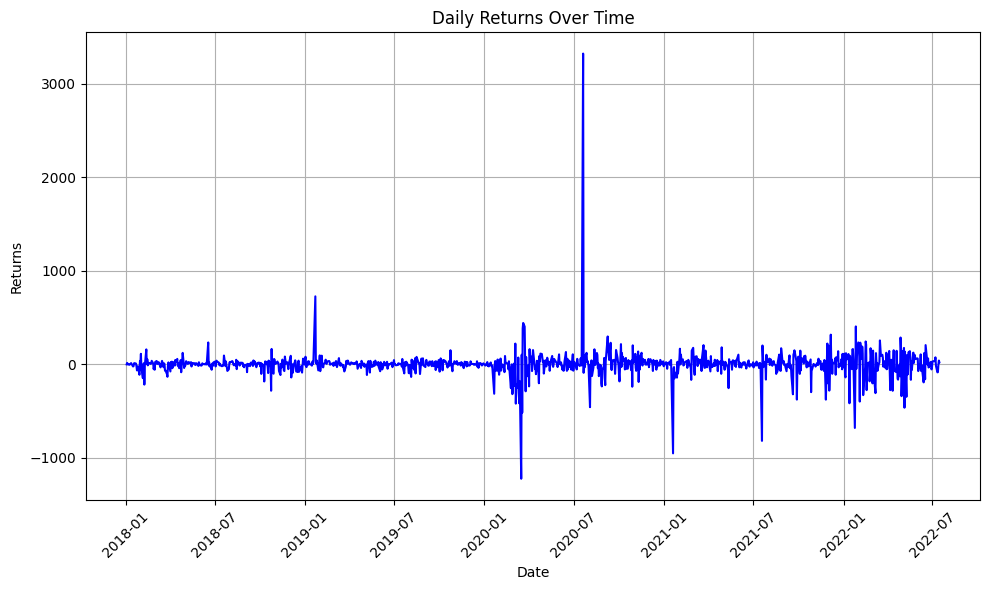

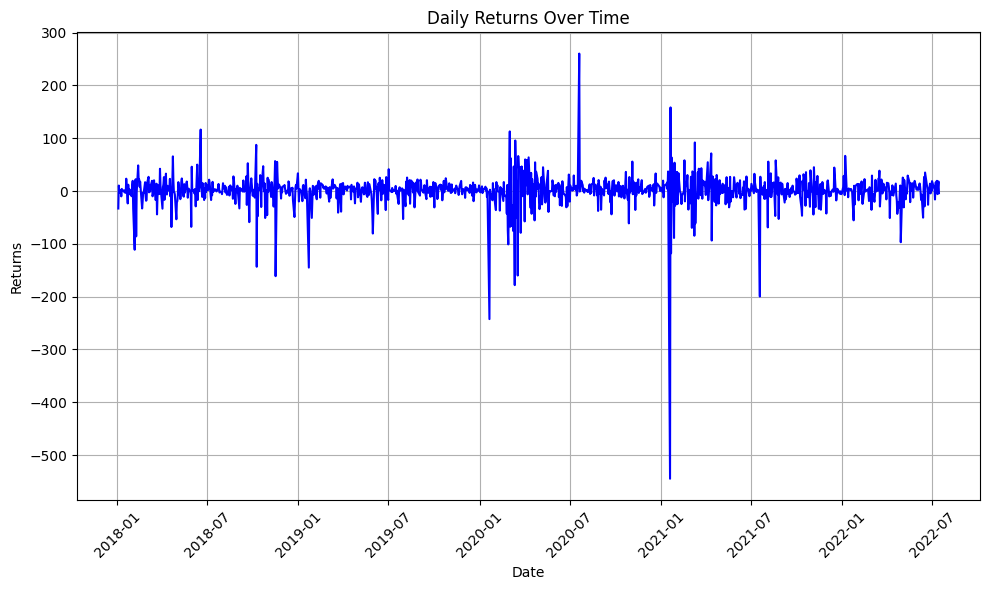

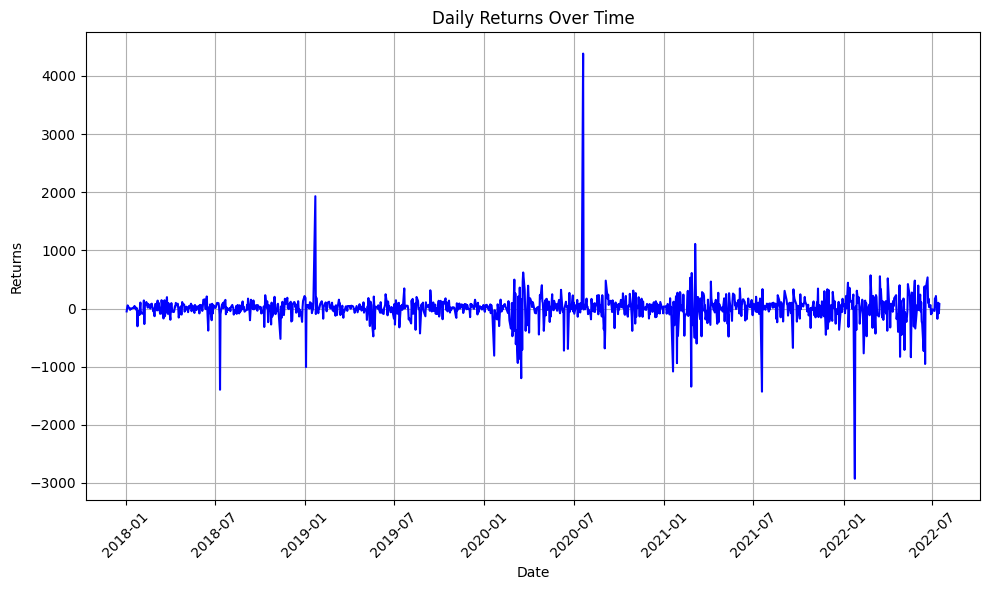

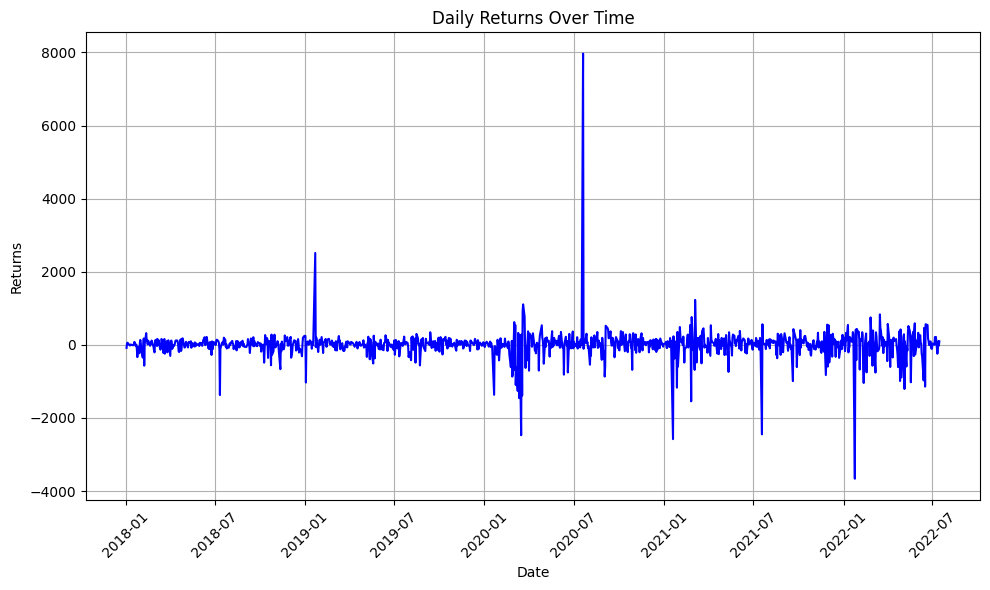

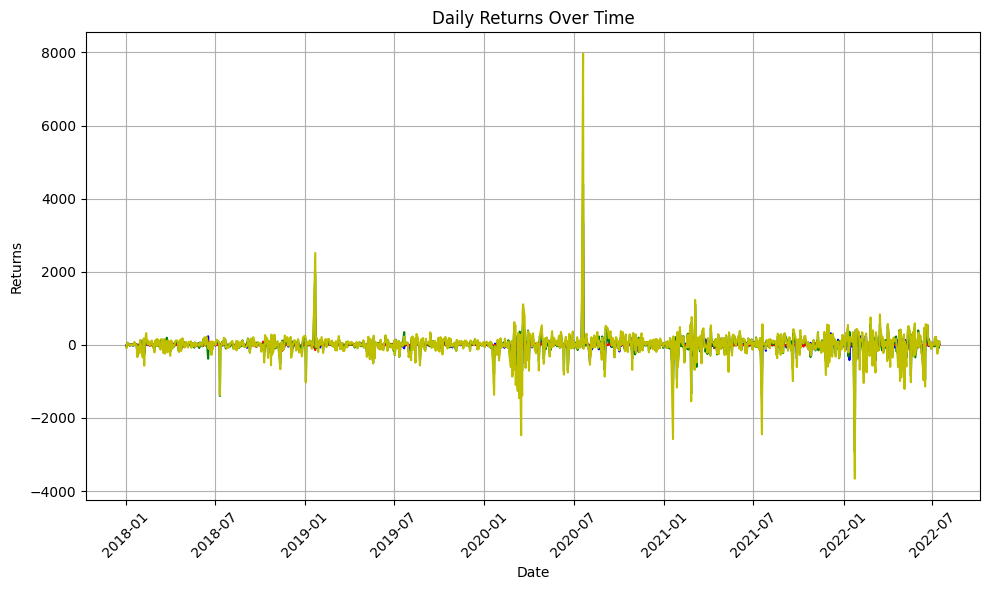

In [14]:
# True Daily PnL Calculations Using a Difference
series_MSFT_daily = series_MSFT.diff().dropna()
series_VZ_daily = series_VZ.diff().dropna()
series_AVGO_daily = series_AVGO.diff().dropna()

plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(series_MSFT_daily.index, series_MSFT_daily.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(series_VZ_daily.index, series_VZ_daily.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(series_AVGO_daily.index, series_AVGO_daily.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

total_daily_returns = series_MSFT_daily.add(series_VZ_daily, fill_value = 0).add(series_AVGO_daily, fill_value = 0)
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(total_daily_returns.index, total_daily_returns.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

# Plot all superimposed
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(series_MSFT_daily.index, series_MSFT_daily.values, linestyle='-', color='b', label='MSFT')  # Plot daily returns
plt.plot(series_VZ_daily.index, series_VZ_daily.values, linestyle='-', color='r', label='VZ')  # Plot daily returns
plt.plot(series_AVGO_daily.index, series_AVGO_daily.values, linestyle='-', color='g', label='AVGO')  # Plot daily returns
plt.plot(total_daily_returns.index, total_daily_returns.values, linestyle='-', color='y', label='Total')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot




In [8]:
# Normalize all series

normalized_MSFT = (series_MSFT - series_MSFT.mean()) / series_MSFT.std()
normalized_VZ = (series_VZ - series_VZ.mean()) / series_VZ.std()
normalized_AVGO = (series_AVGO - series_AVGO.mean()) / series_AVGO.std()



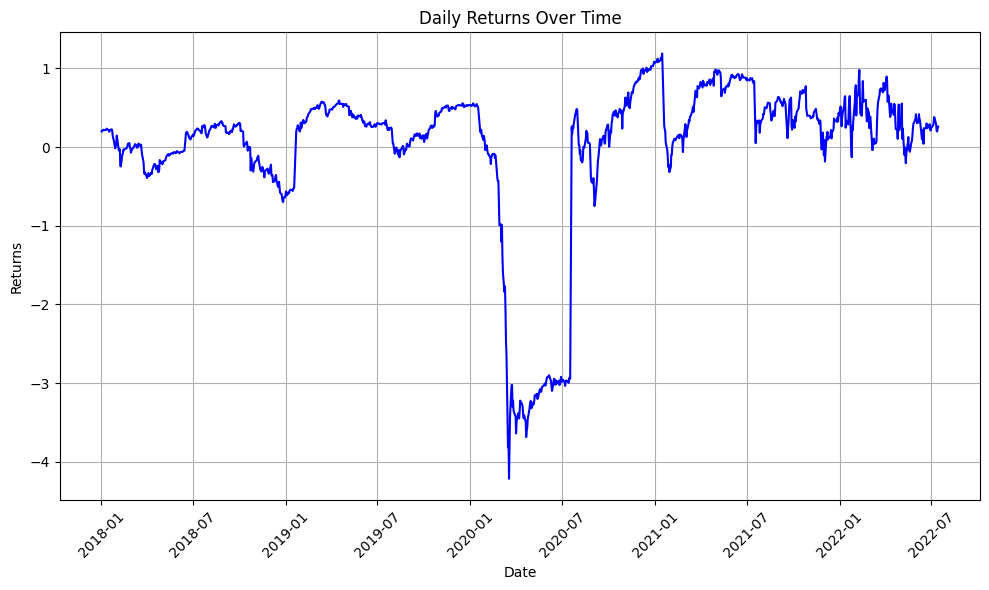

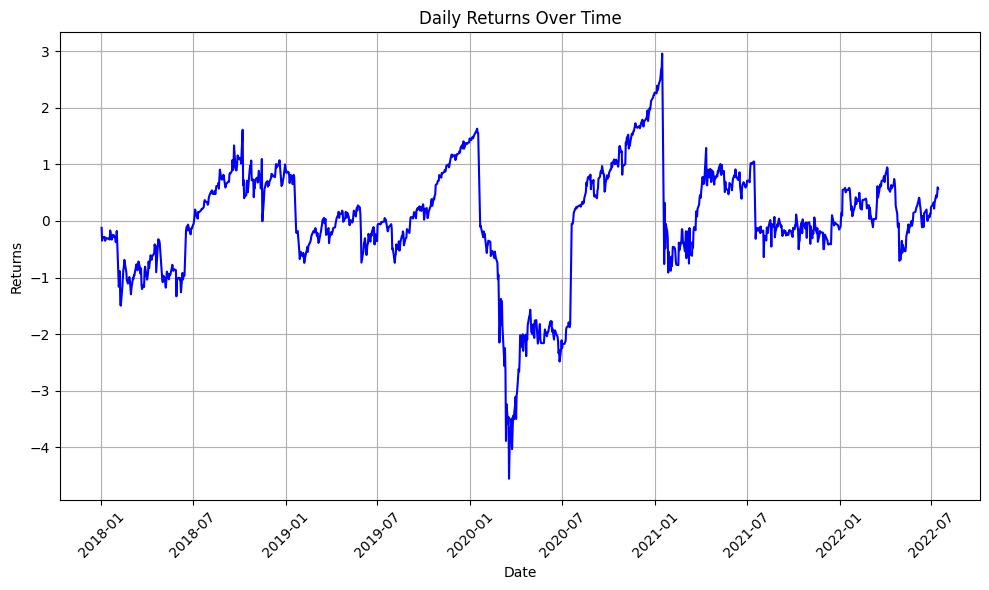

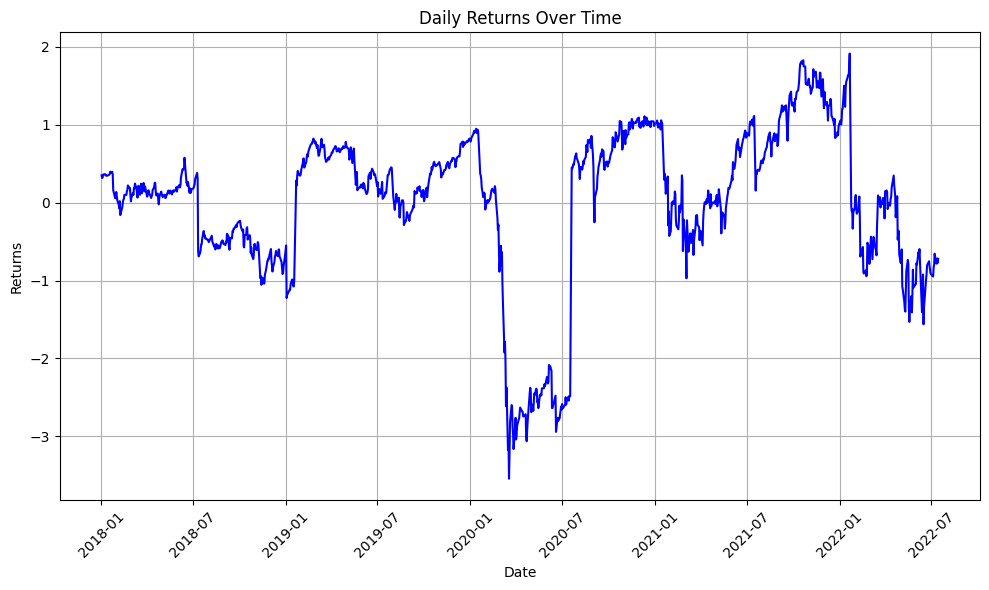

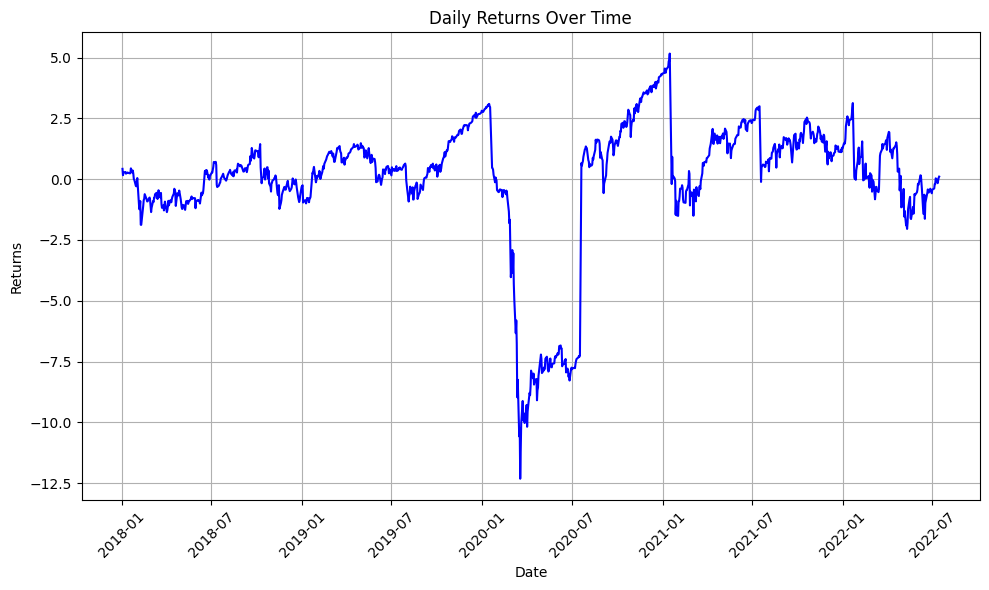

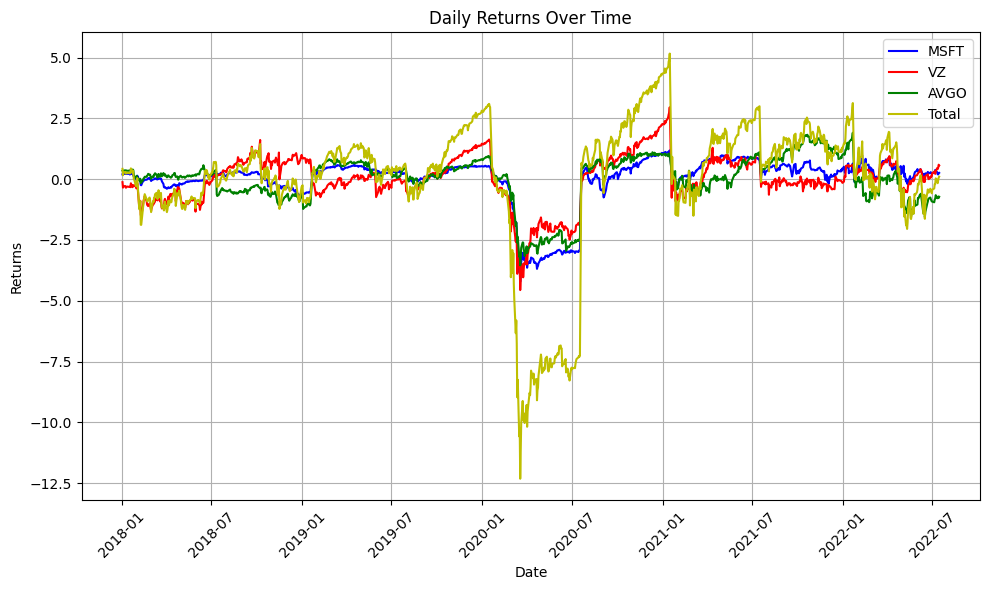

In [11]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(normalized_MSFT.index, normalized_MSFT.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

# VZ
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(normalized_VZ.index, normalized_VZ.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

# AVGO
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(normalized_AVGO.index, normalized_AVGO.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

normalized_total_series = normalized_MSFT + normalized_VZ + normalized_AVGO

plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(normalized_total_series.index, normalized_total_series.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot


# Plot with all 3 stock option strategy returns
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(normalized_MSFT.index, normalized_MSFT.values, linestyle='-', color='b', label='MSFT')  # Plot daily returns
plt.plot(normalized_VZ.index, normalized_VZ.values, linestyle='-', color='r', label='VZ')  # Plot daily returns
plt.plot(normalized_AVGO.index, normalized_AVGO.values, linestyle='-', color='g', label='AVGO')  # Plot daily returns
plt.plot(normalized_total_series.index, normalized_total_series.values, linestyle='-', color='y', label='Total')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.legend()
plt.show()  # Display the plot



In [19]:
series_MSFT_daily = series_MSFT.diff().dropna()
series_VZ_daily = series_VZ.diff().dropna()
series_AVGO_daily = series_AVGO.diff().dropna()


# Standard deviation normalize each

normalized_MSFT_daily = (series_MSFT_daily - series_MSFT_daily.mean()) / series_MSFT_daily.std()
normalized_VZ_daily = (series_VZ_daily - series_VZ_daily.mean()) / series_VZ_daily.std()
normalized_AVGO_daily = (series_AVGO_daily - series_AVGO_daily.mean()) / series_AVGO_daily.std()

# Standard deviations and means of each
print("MSFT Daily Mean: ", series_MSFT_daily.mean())
print("MSFT Daily Std: ", series_MSFT_daily.std())
print("VZ Daily Mean: ", series_VZ_daily.mean())
print("VZ Daily Std: ", series_VZ_daily.std())
print("AVGO Daily Mean: ", series_AVGO_daily.mean())
print("AVGO Daily Std: ", series_AVGO_daily.std())

# Standard deviations and means of each normalized
print("Normalized MSFT Daily Mean: ", normalized_MSFT_daily.mean())
print("Normalized MSFT Daily Std: ", normalized_MSFT_daily.std())
print("Normalized VZ Daily Mean: ", normalized_VZ_daily.mean())
print("Normalized VZ Daily Std: ", normalized_VZ_daily.std())
print("Normalized AVGO Daily Mean: ", normalized_AVGO_daily.mean())
print("Normalized AVGO Daily Std: ", normalized_AVGO_daily.std())
# Correlation matrix
correlation_matrix_normalized = pd.concat([normalized_MSFT_daily, normalized_VZ_daily, normalized_AVGO_daily], axis=1).corr()
print(correlation_matrix_normalized)
correlation_matrix = pd.concat([series_MSFT_daily, series_VZ_daily, series_AVGO_daily], axis=1).corr()
print(correlation_matrix)

# Calculate the Sharpe Ratio
sharpe_ratio_MSFT = series_MSFT_daily.mean() / series_MSFT_daily.std() * math.sqrt(252)
sharpe_ratio_VZ = series_VZ_daily.mean() / series_VZ_daily.std() * math.sqrt(252)
sharpe_ratio_AVGO = series_AVGO_daily.mean() / series_AVGO_daily.std() * math.sqrt(252)
sharpe_ratio_total = total_daily_returns.mean() / total_daily_returns.std() * math.sqrt(252)

print("Sharpe Ratio MSFT: ", sharpe_ratio_MSFT)
print("Sharpe Ratio VZ: ", sharpe_ratio_VZ)
print("Sharpe Ratio AVGO: ", sharpe_ratio_AVGO)
print("Sharpe Ratio Total: ", sharpe_ratio_total)


MSFT Daily Mean:  0.05584592462752269
MSFT Daily Std:  145.8160097688671
VZ Daily Mean:  0.0885801928133214
VZ Daily Std:  32.222087228340754
AVGO Daily Mean:  -1.4027089570552116
AVGO Daily Std:  262.6558674298502
Normalized MSFT Daily Mean:  2.340128285910168e-17
Normalized MSFT Daily Std:  1.0000000000000002
Normalized VZ Daily Mean:  -5.327319070834997e-18
Normalized VZ Daily Std:  1.0
Normalized AVGO Daily Mean:  -6.276019727285066e-18
Normalized AVGO Daily Std:  1.0
          0         1         2
0  1.000000  0.470911  0.726750
1  0.470911  1.000000  0.405606
2  0.726750  0.405606  1.000000
          0         1         2
0  1.000000  0.470911  0.726750
1  0.470911  1.000000  0.405606
2  0.726750  0.405606  1.000000
Sharpe Ratio MSFT:  0.006079761551632964
Sharpe Ratio VZ:  0.043639847340007504
Sharpe Ratio AVGO:  -0.08477752502129939
Sharpe Ratio Total:  -0.05021228305980145


In [ ]:
total_series = series_MSFT + series_VZ + series_AVGO
mean_series = total_series.mean()
print(total_series.size)


In [ ]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(total_series.index, total_series.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

print(statistics.stdev(series_AVGO.values))
print(statistics.mean(series_AVGO.values))

In [ ]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(series_MSFT.index, series_MSFT.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

print(statistics.stdev(series_MSFT.values))
print(statistics.mean(series_MSFT.values))

In [ ]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(series_VZ.index, series_VZ.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

print(statistics.stdev(series_VZ.values))
print(statistics.mean(series_VZ.values))


In [ ]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(series_AVGO.index, series_AVGO.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

print(statistics.stdev(series_AVGO.values))
print(statistics.mean(series_AVGO.values))

In [ ]:
# Plot with all 3 stock option strategy returns
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(series_MSFT.index, series_MSFT.values, linestyle='-', color='b', label='MSFT')  # Plot daily returns
plt.plot(series_VZ.index, series_VZ.values, linestyle='-', color='r', label='VZ')  # Plot daily returns
plt.plot(series_AVGO.index, series_AVGO.values, linestyle='-', color='g', label='AVGO')  # Plot daily returns
plt.plot(total_series.index, total_series.values, linestyle='-', color='y', label='Total')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.legend()
plt.show()  # Display the plot

In [ ]:
# Plot mean
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(mean_series.index, mean_series.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

print(statistics.stdev(series_AVGO.values))
print(statistics.mean(series_AVGO.values))

In [3]:
start_date = pd.Timestamp(2018, 1, 2)
series_MSFT_no = pd.Series()

for i in range(9):

    daily_returns_MSFT_no = eq_strats.backtest_short_straddle_with_premium_change(MSFT_options, MSFT_underlying, risk_free, start_date, 1, 180, False)
    series_MSFT_no = series_MSFT_no.add(daily_returns_MSFT_no.set_index('date')['daily pnl'], fill_value = 0)
    start_date = series_MSFT_no.index[-1]

[('MSFT 180615C95000', 'MSFT 180615P95000')]
[('MSFT 190118C110000', 'MSFT 190118P110000')]
[('MSFT 190719C115000', 'MSFT 190719P115000')]
[('MSFT 200117C140000', 'MSFT 200117P140000')]
[('MSFT 200717C155000', 'MSFT 200717P155000')]
[('MSFT 210115C200000', 'MSFT 210115P200000')]
[('MSFT 210716C215000', 'MSFT 210716P215000')]
[('MSFT 220121C300000', 'MSFT 220121P300000')]
[('MSFT 220715C310000', 'MSFT 220715P310000')]


In [4]:
start_date = pd.Timestamp(2018, 1, 2)
series_VZ_no = pd.Series()

for i in range(9):
    daily_returns_VZ_no = eq_strats.backtest_short_straddle_with_premium_change(VZ_options, VZ_underlying, risk_free, start_date, 1, 180, False)
    series_VZ_no = series_VZ_no.add(daily_returns_VZ_no.set_index('date')['daily pnl'], fill_value = 0)
    start_date = series_VZ_no.index[-1]

[('VZ 180615C52500', 'VZ 180615P52500')]
[('VZ 190118C49000', 'VZ 190118P49000')]
[('VZ 190719C60000', 'VZ 190719P60000')]
[('VZ 200117C57500', 'VZ 200117P57500')]
[('VZ 200717C62500', 'VZ 200717P62500')]
[('VZ 210115C57500', 'VZ 210115P57500')]
[('VZ 210716C62500', 'VZ 210716P62500')]
[('VZ 220121C60000', 'VZ 220121P60000')]
[('VZ 220715C50000', 'VZ 220715P50000')]


In [5]:
start_date = pd.Timestamp(2018, 1, 2)
series_AVGO_no = pd.Series()

for i in range(9):
    daily_returns_AVGO_no = eq_strats.backtest_short_straddle_with_premium_change(AVGO_options, AVGO_underlying, risk_free, start_date, 1, 180, False)
    series_AVGO_no = series_AVGO_no.add(daily_returns_AVGO_no.set_index('date')['daily pnl'], fill_value = 0)
    start_date = series_AVGO_no.index[-1]

[('AVGO 180615C270000', 'AVGO 180615P270000')]
[('AVGO 190118C260000', 'AVGO 190118P260000')]
[('AVGO 190719C280000', 'AVGO 190719P280000')]
[('AVGO 200117C290000', 'AVGO 200117P290000')]
[('AVGO 200717C280000', 'AVGO 200717P280000')]
[('AVGO 210115C300000', 'AVGO 210115P300000')]
[('AVGO 210716C450000', 'AVGO 210716P450000')]
[('AVGO 220121C500000', 'AVGO 220121P500000')]
[('AVGO 220715C530000', 'AVGO 220715P530000')]


In [6]:
total_series_no = series_MSFT_no + series_VZ_no + series_AVGO_no
mean_series_no = total_series_no.mean()
print(total_series_no.size)

1142


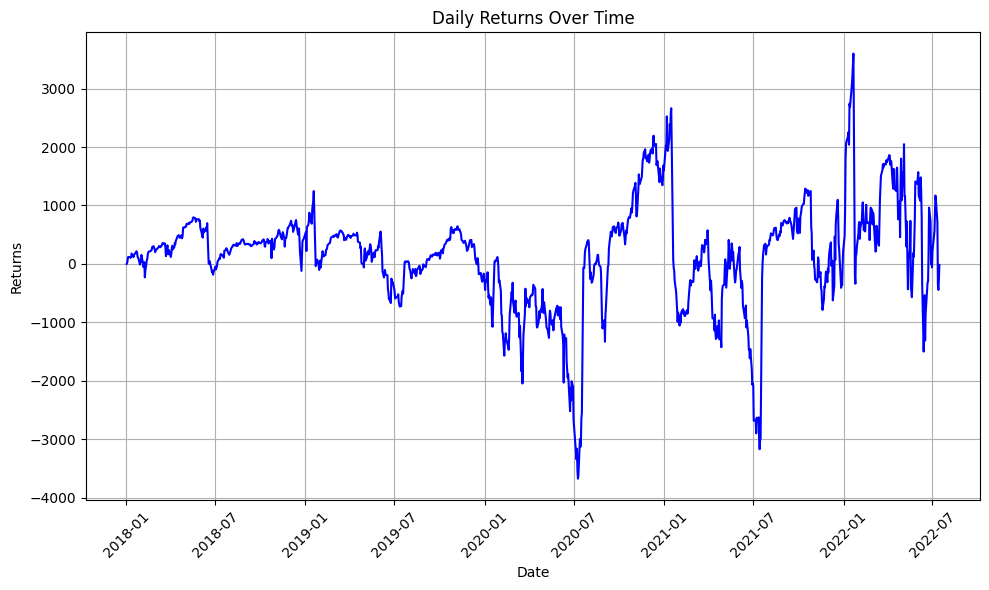

903.5382350832542
149.66199649737305


In [11]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(series_MSFT_no.index, series_MSFT_no.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

print(statistics.stdev(series_MSFT_no.values))
print(statistics.mean(series_MSFT_no.values))

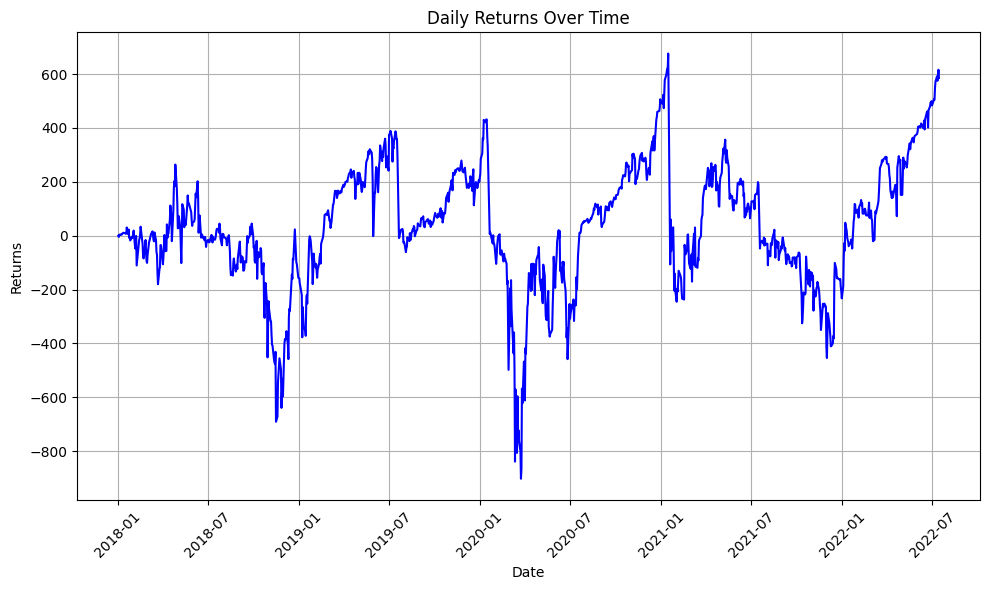

225.66883423029944
32.15630472854641


In [12]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(series_VZ_no.index, series_VZ_no.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

print(statistics.stdev(series_VZ_no.values))
print(statistics.mean(series_VZ_no.values))


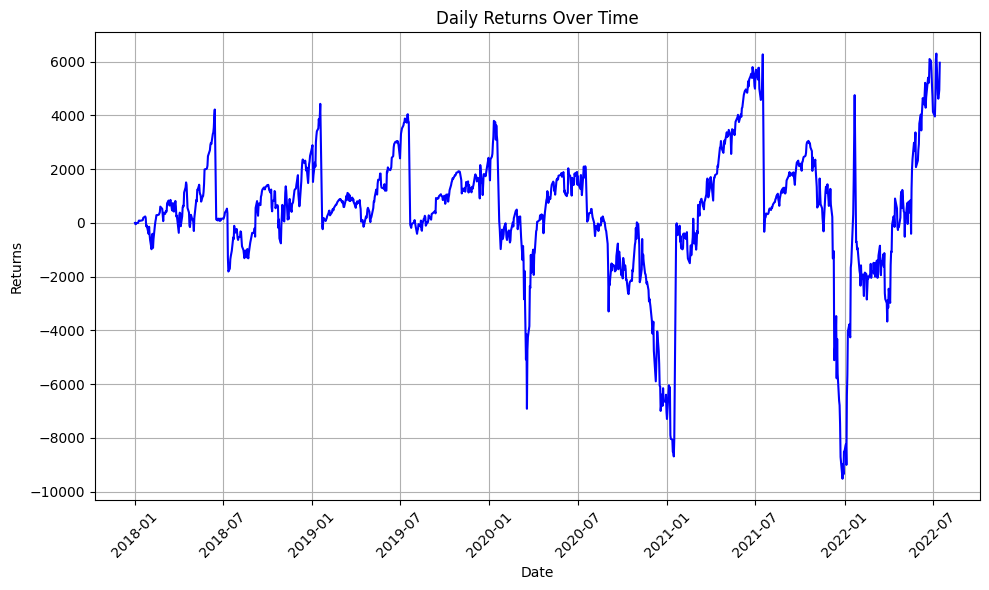

2354.431764251418
482.22941943957966


In [13]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(series_AVGO_no.index, series_AVGO_no.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

print(statistics.stdev(series_AVGO_no.values))
print(statistics.mean(series_AVGO_no.values))

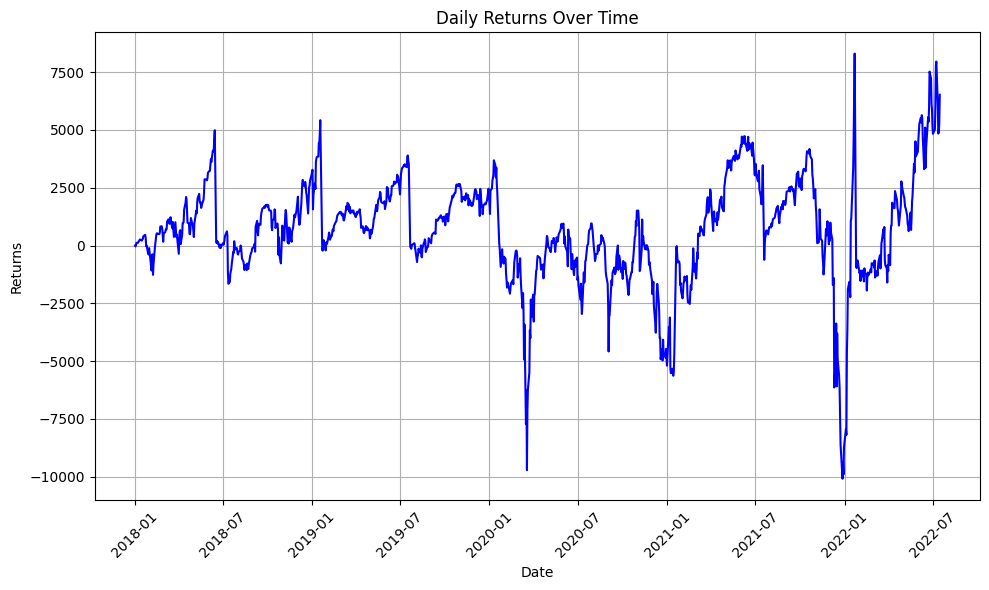

2270.2256195552063
664.0477206654991


In [15]:
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(total_series_no.index, total_series_no.values, linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

print(statistics.stdev(total_series_no.values))
print(statistics.mean(total_series_no.values))

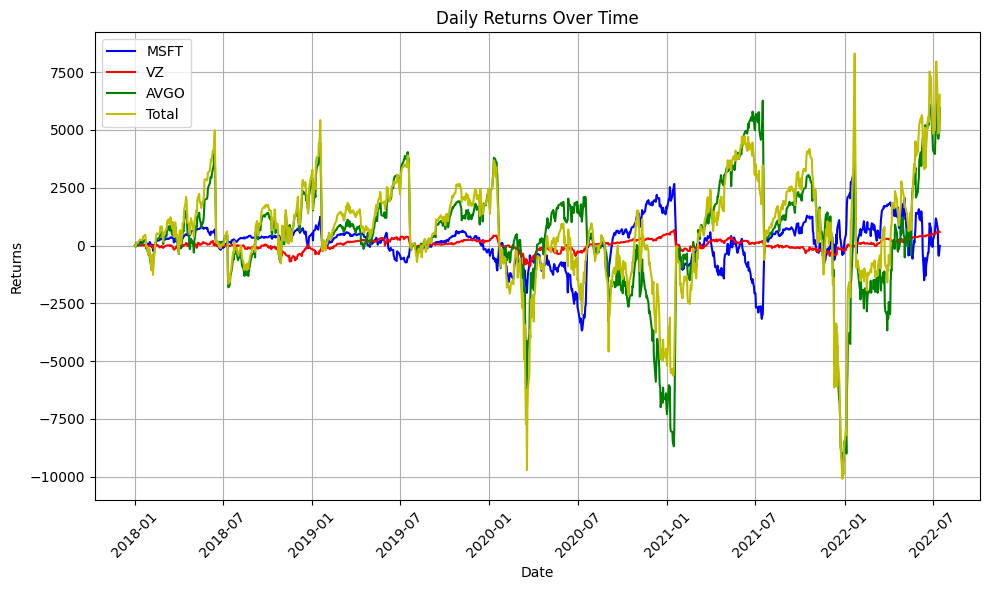

In [16]:
# Plot with all 3 stock option strategy returns
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(series_MSFT_no.index, series_MSFT_no.values, linestyle='-', color='b', label='MSFT')  # Plot daily returns
plt.plot(series_VZ_no.index, series_VZ_no.values, linestyle='-', color='r', label='VZ')  # Plot daily returns
plt.plot(series_AVGO_no.index, series_AVGO_no.values, linestyle='-', color='g', label='AVGO')  # Plot daily returns
plt.plot(total_series_no.index, total_series_no.values, linestyle='-', color='y', label='Total')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.legend()
plt.show()  # Display the plot